# 03 · Water-Source Heat Pump (WSHP) CEA Greenhouse Simulation
### Dynamic 52,560-Hour (6-Year) Surface Aquifer/Canal Loop Simulation

**Author**: Fraser James Mclellan  
**Academic Basis**: BEng (Hons) Individual Project Thesis (Grade A4, First-Class Honours), University of Glasgow  
**Domain**: Hydronic Heat Extraction & High-Efficiency Low-Carbon Thermal Systems  

---

## 1. Thermodynamic Context & Water Source Dynamics

Surface water bodies (rivers, canals, retention ponds, and shallow aquifers) possess substantial volumetric heat capacities. Even during severe sub-zero winter spells, water bodies remain stratified, providing heat pump evaporators with significantly elevated source temperatures ($+4^\circ\text{C}$ to $+8^\circ\text{C}$) compared to sub-zero ambient air.

In this model, the two-stage ammonia heat pump evaporator is coupled to an open/closed surface water loop.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 1.6,
    'figure.dpi': 150
})

data_dir = '../data'
df_ws = pd.read_csv(f'{data_dir}/outputs/results_water_source.csv')
df_hl = pd.read_csv(f'{data_dir}/outputs/greenhouse_heat_load.csv')

print(f"Loaded WSHP results ({len(df_ws)} hours).")


Loaded WSHP results (52560 hours).


## 2. Audited Performance Metrics (WSHP)
- **Mean Seasonal COP**: $\mathbf{4.29}$ (highest across all topologies)
- **Peak Compressor Electrical Demand**: $\mathbf{62.71\,\text{kW}}$ (a **$19.33\,\text{kW}$ / $23.6\%$ peak load reduction** compared to ASHP)
- **Total 6-Year Electricity Demand**: $\mathbf{827.1\,\text{MWh}}$
- **6-Year Energy Savings**: $\mathbf{58,995\,\text{kWh} \approx 59\,\text{MWh}$ saved relative to ASHP.


In [2]:
active_mask = df_ws['W_total_kW'] > 0
active_cop = df_ws.loc[active_mask, 'COP']
peak_comp_kw = df_ws['W_total_kW'].max()
total_kwh = df_ws['W_total_kW'].sum()
total_mwh = total_kwh / 1000.0

print("=== AUDITED WATER-SOURCE HEAT PUMP (WSHP) METRICS ===")
print(f"• Peak Electrical Compressor Demand: {peak_comp_kw:.2f} kW (vs ASHP 82.04 kW)")
print(f"• Mean Active COP:                  {active_cop.mean():.2f}")
print(f"• 6-Year Total Electricity Demand:  {total_mwh:.1f} MWh ({total_kwh:,.0f} kWh)")
print(f"• 6-Year Energy Savings vs ASHP:    {(886055.1 - total_kwh)/1000:.1f} MWh")


=== AUDITED WATER-SOURCE HEAT PUMP (WSHP) METRICS ===
• Peak Electrical Compressor Demand: 62.71 kW (vs ASHP 82.04 kW)
• Mean Active COP:                  4.16
• 6-Year Total Electricity Demand:  827.1 MWh (827,060 kWh)
• 6-Year Energy Savings vs ASHP:    59.0 MWh


## 3. High COP Stability Profile
We plot the COP distribution across all operating hours for the water-source topology.


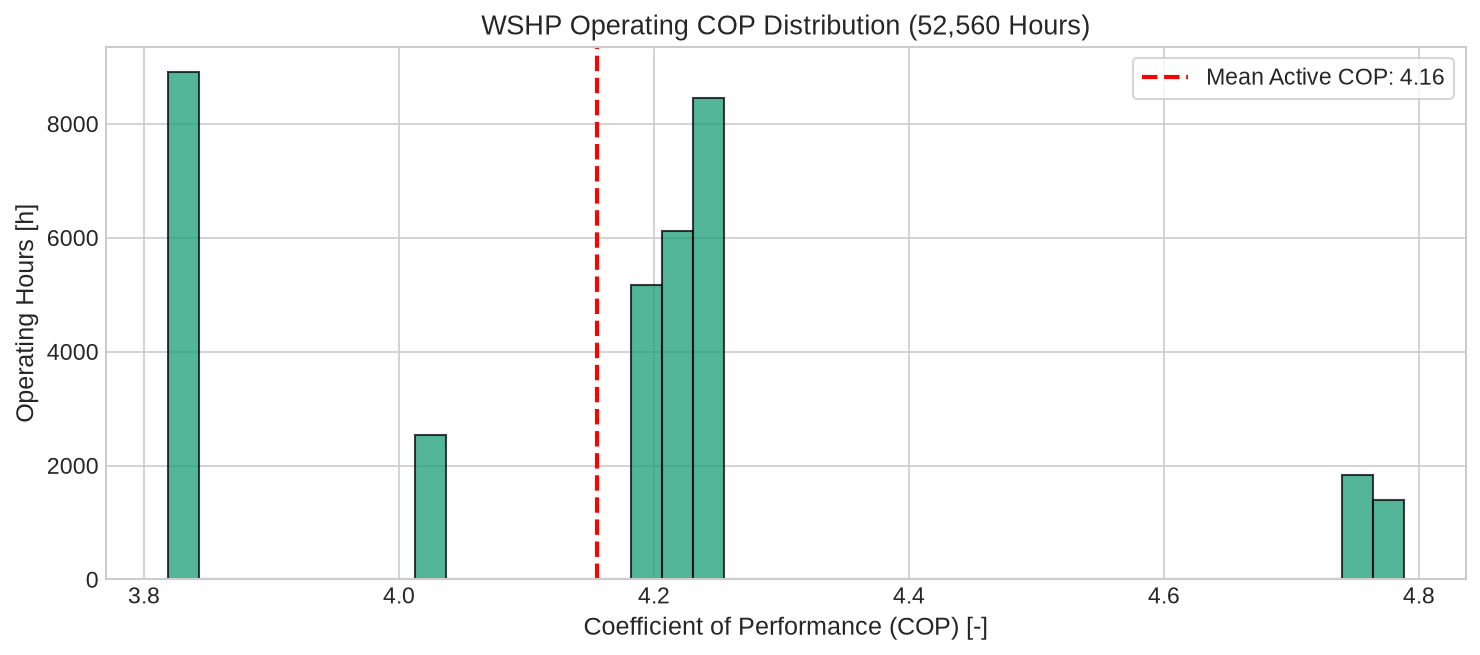

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(df_ws.loc[active_mask, 'COP'], bins=40, color='#1b9e77', edgecolor='black', alpha=0.75)
ax.axvline(active_cop.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Active COP: {active_cop.mean():.2f}')
ax.set_xlabel('Coefficient of Performance (COP) [-]')
ax.set_ylabel('Operating Hours [h]')
ax.set_title('WSHP Operating COP Distribution (52,560 Hours)')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()
